### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [32]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df.sort_values(by="total_litres_of_pure_alcohol",ascending=False,inplace=True)
df.head(10)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
15,Belarus,142,373,42,14.4
98,Lithuania,343,244,56,12.9
3,Andorra,245,138,312,12.4
68,Grenada,199,438,28,11.9
61,France,127,151,370,11.8
45,Czech Republic,361,170,134,11.8
141,Russian Federation,247,326,73,11.5
99,Luxembourg,236,133,271,11.4
155,Slovakia,196,293,116,11.4
81,Ireland,313,118,165,11.4


In [31]:
df[['beer_servings',"spirit_servings","wine_servings"]].mean()

beer_servings      106.160622
spirit_servings     80.994819
wine_servings       49.450777
dtype: float64

In [39]:
df["alcohol_index"] = ((df["beer_servings"] + df["wine_servings"] + df["spirit_servings"]) / 3).astype(float)
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
15,Belarus,142,373,42,14.4,185.666667
98,Lithuania,343,244,56,12.9,214.333333
3,Andorra,245,138,312,12.4,231.666667
68,Grenada,199,438,28,11.9,221.666667
61,France,127,151,370,11.8,216.000000
...,...,...,...,...,...,...
97,Libya,0,0,0,0.0,0.000000
103,Maldives,0,0,0,0.0,0.000000
111,Monaco,0,0,0,0.0,0.000000
158,Somalia,0,0,0,0.0,0.000000


In [44]:
df["alcohol_index"].idxmax()
df.loc[3]

country                            Andorra
beer_servings                          245
spirit_servings                        138
wine_servings                          312
total_litres_of_pure_alcohol          12.4
alcohol_index                   231.666667
Name: 3, dtype: object

In [47]:
#* Filtra solo i paesi che consumano più di 100 birre all’anno

df[df["beer_servings"]>100]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
15,Belarus,142,373,42,14.4,185.666667
98,Lithuania,343,244,56,12.9,214.333333
3,Andorra,245,138,312,12.4,231.666667
68,Grenada,199,438,28,11.9,221.666667
61,France,127,151,370,11.8,216.000000
...,...,...,...,...,...,...
29,Cabo Verde,144,56,16,4.0,72.000000
170,Macedonia,106,27,86,3.9,73.000000
20,Bolivia,167,41,8,3.8,72.000000
146,Samoa,105,18,24,2.6,49.000000


Text(0.5, 1.0, 'Top 10 paesi per consumo di alcol')

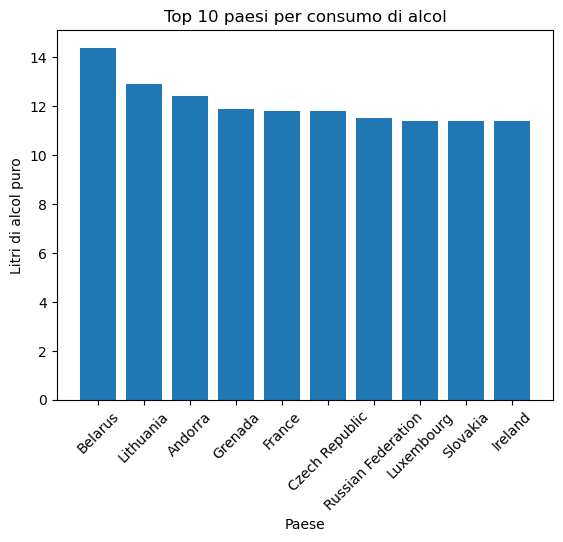

In [59]:
#Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)
import matplotlib.pyplot as plt
dt=df.sort_values(by="total_litres_of_pure_alcohol",ascending=False,inplace=False)
dt=dt.head(10)
plt.bar(dt["country"], dt["total_litres_of_pure_alcohol"])
plt.xticks(rotation=45)
plt.xlabel("Paese")
plt.ylabel("Litri di alcol puro")
plt.title("Top 10 paesi per consumo di alcol")

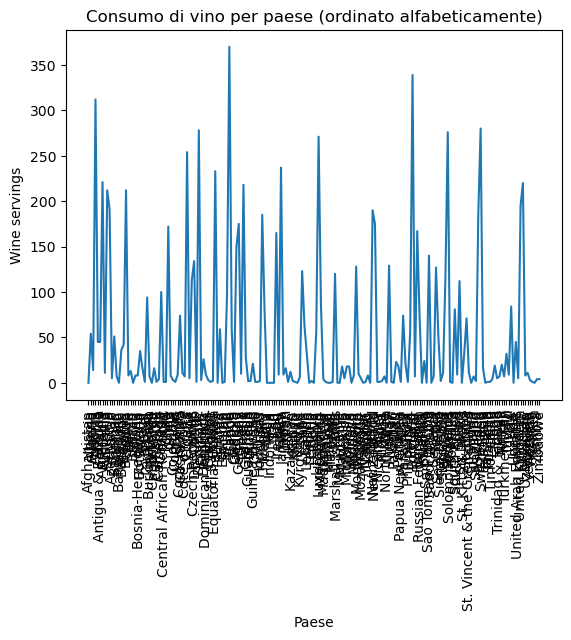

In [64]:
df_sorted=df.sort_values(by="country")

plt.plot(df_sorted["country"], df_sorted["wine_servings"])
plt.xticks(rotation=90)
plt.xlabel("Paese")
plt.ylabel("Wine servings")
plt.title("Consumo di vino per paese (ordinato alfabeticamente)")
plt.show()



### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [18]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [9]:
df.dropna(subset=["salary_year_avg"],inplace=True)
df["salary_year_avg"].mean

<bound method Series.mean of 28        109500.0
77        140000.0
92        120000.0
100       228222.0
109        89000.0
            ...   
785624    139216.0
785641    150000.0
785648    221875.0
785682    157500.0
785692    157500.0
Name: salary_year_avg, Length: 22003, dtype: float64>

In [13]:
len(df)

785741

In [ ]:
df.dropna(subset=["salary_year_avg"],inplace=True)

df["salary_year_avg"].min(),df["salary_year_avg"].max()



(np.float64(15000.0), np.float64(960000.0))

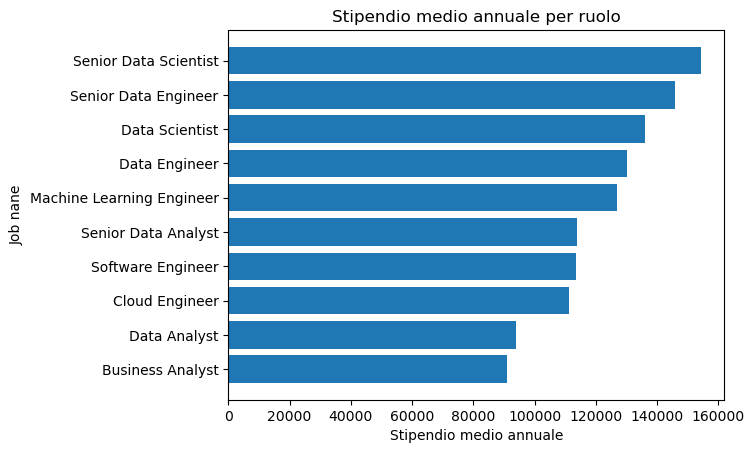

In [ ]:
import matplotlib.pyplot as plt
df.dropna(subset=["salary_year_avg"],inplace=True)

avg_salary = (df.groupby("job_title_short")["salary_year_avg"].mean().sort_values(ascending=False))

plt.figure()
plt.barh(avg_salary.index, avg_salary.values)

plt.gca().invert_yaxis()

plt.xlabel("Stipendio medio annuale")
plt.ylabel("Job nane")
plt.title("Stipendio medio annuale per ruolo")

plt.show()



### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [23]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [37]:
df = df.groupby("day").agg(
    conto_medio=("total_bill", "mean"),
    numero_osservazioni=("total_bill", "count"),
    minimo=("total_bill", "min"),
    massimo=("total_bill", "max")
)

df

,conto_medio,numero_osservazioni,minimo,massimo
day,,,,
Fri,17.151579,19,5.75,40.17
Sat,20.441379,87,3.07,50.81
Sun,21.410000,76,7.25,48.17
Thur,17.682742,62,7.51,43.11


In [28]:
df["conto_per_persona"] = df["total_bill"] / df["size"]
df

,total_bill,tip,sex,smoker,day,time,size,conto_per_persona
0,16.99,1.01,Female,No,Sun,Dinner,2,8.495000
1,10.34,1.66,Male,No,Sun,Dinner,3,3.446667
2,21.01,3.50,Male,No,Sun,Dinner,3,7.003333
3,23.68,3.31,Male,No,Sun,Dinner,2,11.840000
4,24.59,3.61,Female,No,Sun,Dinner,4,6.147500
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,9.676667
240,27.18,2.00,Female,Yes,Sat,Dinner,2,13.590000
241,22.67,2.00,Male,Yes,Sat,Dinner,2,11.335000
242,17.82,1.75,Male,No,Sat,Dinner,2,8.910000


In [ ]:
df["conto_medio"].idxmax()

'Sun'

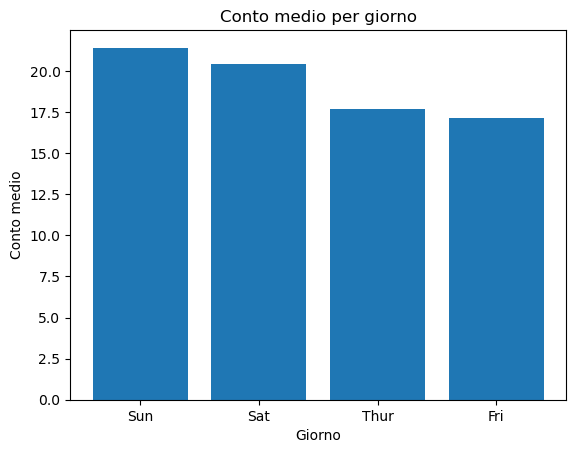

In [45]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values(by="conto_medio", ascending=False)

plt.figure()
plt.bar(df_sorted.index, df_sorted["conto_medio"])

plt.xlabel("Giorno")
plt.ylabel("Conto medio")
plt.title("Conto medio per giorno")
plt.show()